In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys

In [32]:
# Results path
results_dir = os.path.join('..', '..', 'experiments', 'revision')
fig_dir = os.path.join(results_dir, 'figures')
os.makedirs(fig_dir, exist_ok=True)

In [127]:
formal_names = {
    'knn1024': 'kNN',
    'convnet128': 'ConvNet',
    'sit512': 'SiT',
    'resnet1024': 'ResNet',
    'average': 'Av',
    'vote': 'V',
}

plt.rcParams.update({'font.size': 14})
meanprops = {"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}

palette = {
    'sit512': "#FFB522",
    'convnet128': "#4494FF",
    'resnet1024': "#0048FF",
    'knn1024': "#91AAC2",
}

In [81]:
# models = os.listdir(results_dir
models = ['knn1024', 'convnet128', 'sit512', 'resnet1024']
dfs = []

for model in models:
    model_dir = os.path.join(results_dir, model)
    files = os.listdir(model_dir)
    for file in files:
        combination_method = file.split('_')[1]
        k = file.split('_')[2].replace('.csv', '')
        model_name = f"{formal_names[model]}-{formal_names[combination_method]}{k}"
        curr_df = pd.read_csv(os.path.join(model_dir, file), index_col=0)
        curr_df['k'] = k
        curr_df['Combination method'] = combination_method
        curr_df['Model'] = model
        curr_df['Model name'] = model_name
        dfs.append(curr_df)
df = pd.concat(dfs)
df.sample(3)

,AUC_ROC,AUC_PR,Precision,Recall,F,Precision_at_k,Rprecision,Rrecall,RF,R_AUC_ROC,...,weight_LSTM,weight_MP,weight_NORMA,weight_OCSVM,weight_PCA,weight_POLY,k,Combination method,Model,Model name
SVDB/801.test.csv@1.out,0.942313,0.639720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.938071,...,0.0,0.023364,0.443925,0.00000,0.532710,0.0,3,vote,knn1024,kNN-V3
KDD21/230_UCR_Anomaly_mit14134longtermecg_19363_19510_19610.out,0.402915,0.001293,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.418331,...,0.0,0.048443,0.602076,0.00346,0.235294,0.0,8,average,knn1024,kNN-Av8
OPPORTUNITY/S2-ADL5.test.csv@81.out,0.908469,0.576967,0.914286,0.027634,0.053646,0.027634,0.666667,0.109001,0.187368,0.910684,...,0.0,0.000000,0.833333,0.00000,0.100000,0.0,3,vote,knn1024,kNN-V3


In [147]:
df['Affiliation_F'] = (2 * df['Affiliation_Precision'] * df['Affiliation_Recall']) / (df['Affiliation_Precision'] + df['Affiliation_Recall'])

In [148]:
reindexed_df = df.reset_index()
reindexed_df

,index,AUC_ROC,AUC_PR,Precision,Recall,F,Precision_at_k,Rprecision,Rrecall,RF,...,weight_MP,weight_NORMA,weight_OCSVM,weight_PCA,weight_POLY,k,Combination method,Model,Model name,Affiliation_F
0,SVDB/840.test.csv@1.out,0.995519,0.886235,0.763359,0.868726,0.812641,0.868726,0.366283,0.454644,0.405709,...,0.021352,0.633452,0.000000,0.115658,0.003559,8,average,knn1024,kNN-Av8,0.734899
1,SVDB/847.test.csv@2.out,0.961294,0.703772,0.824909,0.305858,0.446255,0.305858,0.776240,0.240480,0.367201,...,0.021352,0.607651,0.000000,0.150356,0.004448,8,average,knn1024,kNN-Av8,0.388637
2,SVDB/852.test.csv@2.out,0.873901,0.465650,0.549435,0.055349,0.100568,0.055349,0.541710,0.066787,0.118913,...,0.023132,0.601423,0.000000,0.145907,0.000000,8,average,knn1024,kNN-Av8,0.384834
3,SVDB/809.test.csv@1.out,0.990395,0.856826,0.754819,0.799042,0.776301,0.799042,0.396583,0.415135,0.405647,...,0.037400,0.729297,0.003562,0.102404,0.000000,8,average,knn1024,kNN-Av8,0.782971
4,SVDB/857.test.csv@2.out,0.989670,0.891253,0.957521,0.365991,0.529567,0.365991,0.969198,0.421147,0.587156,...,0.036477,0.773132,0.000000,0.089858,0.000000,8,average,knn1024,kNN-Av8,0.710999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3971,IOPS/KPI-05f10d3a-239c-3bef-9bdc-a2feeb0037aa....,0.973688,0.531110,0.401770,0.706615,0.512271,0.706615,0.323504,0.888235,0.474273,...,0.000000,0.000000,0.000000,0.006993,0.993007,4,vote,resnet1024,ResNet-V4,0.435197
3972,IOPS/KPI-7103fa0f-cac4-314f-addc-866190247439....,0.985817,0.093921,0.043697,0.945455,0.083534,0.945455,0.038334,0.942857,0.073673,...,0.000000,0.000000,0.000000,0.000000,0.000000,4,vote,resnet1024,ResNet-V4,0.271996
3973,IOPS/KPI-8723f0fb-eaef-32e6-b372-6034c9c04b80....,0.883668,0.204881,0.268187,0.609125,0.372409,0.609125,0.190056,0.789240,0.306342,...,0.000000,0.020548,0.000000,0.184932,0.760274,4,vote,resnet1024,ResNet-V4,0.863216
3974,MGAB/2.test.out,0.999432,0.668286,0.632727,0.870000,0.732632,0.870000,0.710043,0.870000,0.781925,...,0.000000,0.000000,0.000000,0.000000,0.000000,4,vote,resnet1024,ResNet-V4,0.461200


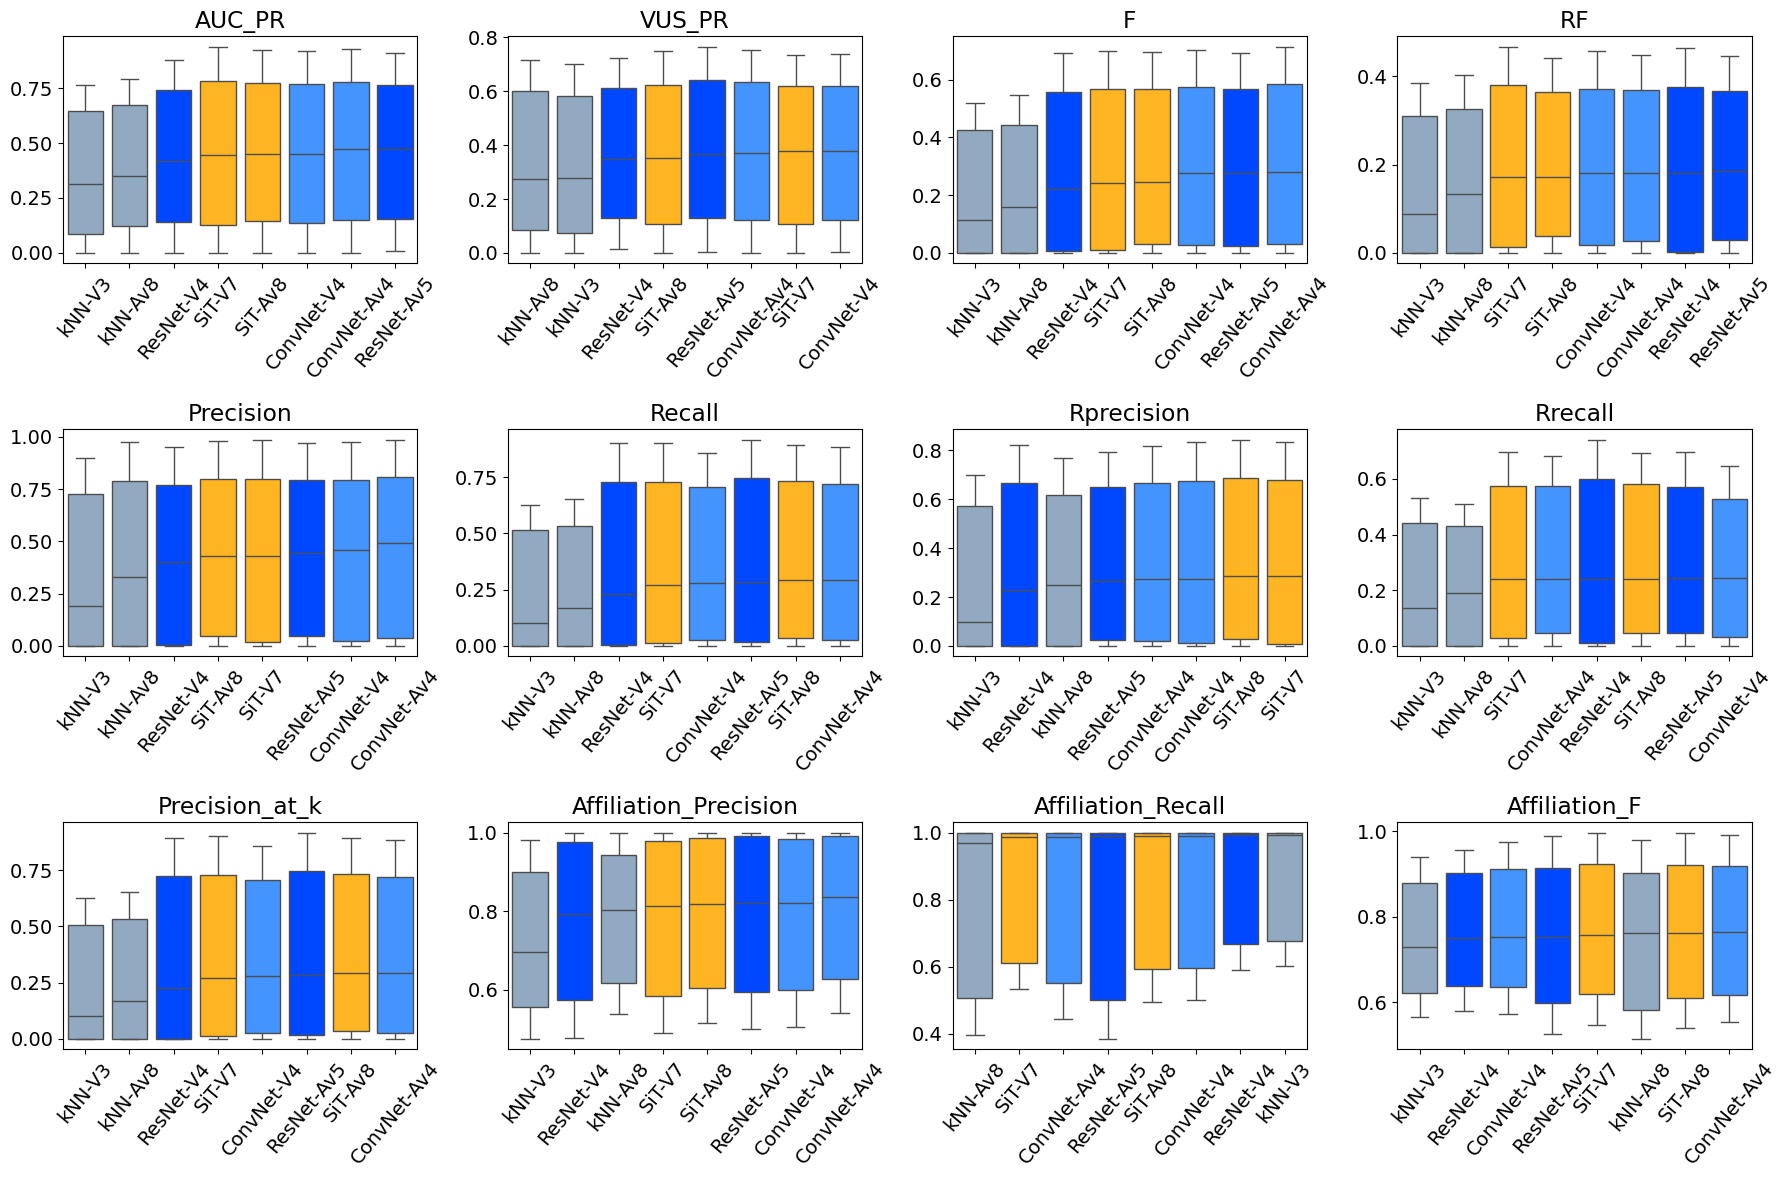

In [182]:
# measures = ['Precision', 'Recall', 'F', 'Precision_at_k', 'Rprecision', 'Rrecall', 'RF', 'Affiliation_Precision', 'Affiliation_Recall', 'Affiliation_F', 'VUS_PR', 'AUC_PR'] #, 'R_AUC_ROC', 'R_AUC_PR''AUC_ROC', , 'VUS_ROC'
measures = [
    'AUC_PR', 'VUS_PR', 'F', 'RF',
    'Precision', 'Recall', 'Rprecision', 'Rrecall',
    'Precision_at_k', 'Affiliation_Precision', 'Affiliation_Recall', 'Affiliation_F',
]
fig, ax = plt.subplots(3, 4, figsize=(18, 12))

for measure, axis in zip(measures, ax.flatten()):
    sorted_models = list(df.groupby('Model name')[measure].median().sort_values().index)
    
    sns.boxplot(
        ax=axis,
        data=reindexed_df,
        y=measure,
        x='Model name',
        order=sorted_models,
        whis=0.241289844,
        showfliers=False,
        showmeans=False,
        meanprops=meanprops,
        palette=palette,
        saturation=1,
        hue="Model",
        legend=False,
    )
    axis.set_xlabel('')
    axis.tick_params(axis='x', labelrotation=50)
    axis.set_title(measure)
    axis.set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "all_measures.pdf"))
plt.show()
plt.close()

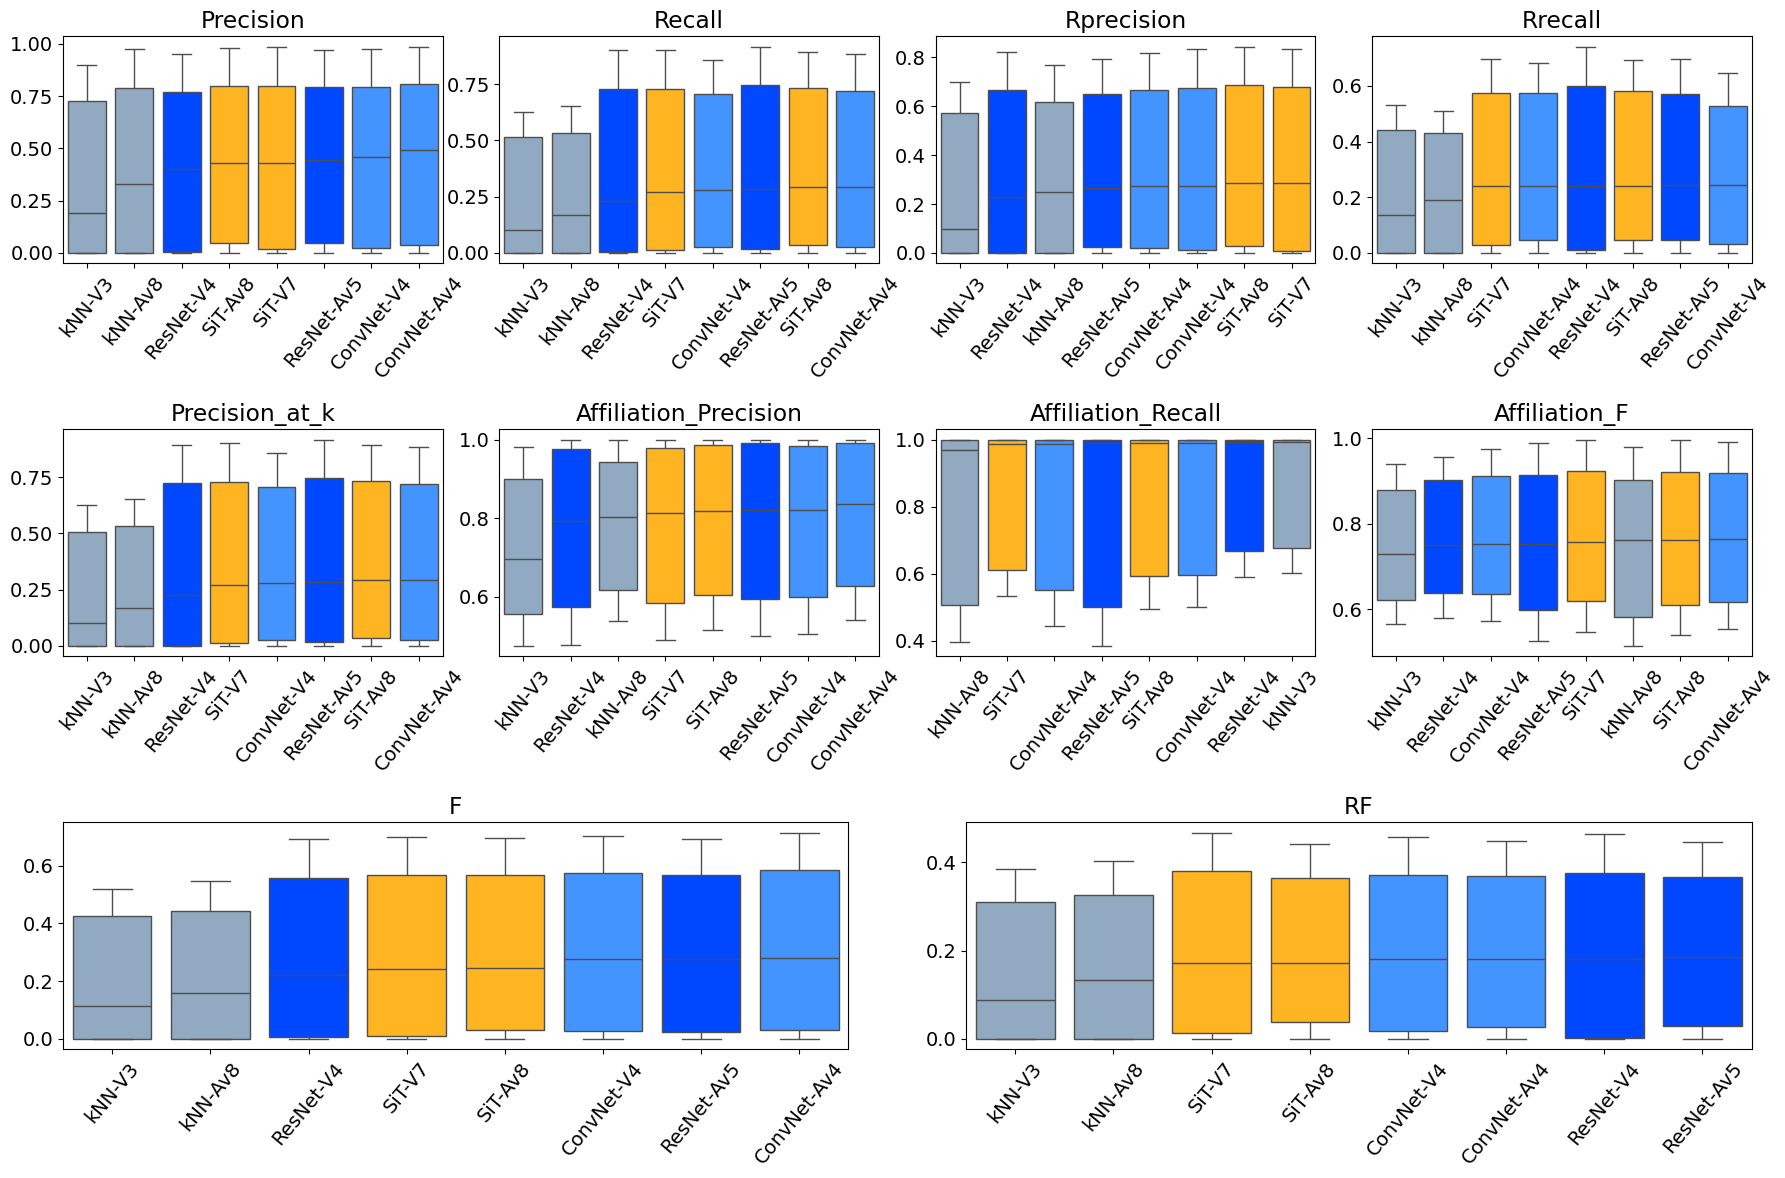

In [181]:
measures = [
    # First row: Core precision/recall metrics
    'Precision', 'Recall', 'Rprecision', 'Rrecall',

    # Second row: Specialized precision/recall variants
    'Precision_at_k', 'Affiliation_Precision', 'Affiliation_Recall', 'Affiliation_F',

    # Third row: Key composite metrics (wide plots)
    'F', 'RF'
]
fig = plt.figure(figsize=(18, 12))

for i, measure in enumerate(measures):
    sorted_models = list(df.groupby('Model name')[measure].median().sort_values().index)
    if i < 8:
        axis = fig.add_subplot(3, 4, i + 1)
    else:
        axis = fig.add_subplot(3, 2, 5 + (i % 2))
    
    sns.boxplot(
        ax=axis,
        data=reindexed_df,
        y=measure,
        x='Model name',
        order=sorted_models,
        whis=0.241289844,
        showfliers=False,
        showmeans=False,
        meanprops=meanprops,
        palette=palette,
        saturation=1,
        hue="Model",
        legend=False,
    )
    axis.set_xlabel('')
    axis.tick_params(axis='x', labelrotation=50)
    axis.set_title(measure)
    axis.set_ylabel('')

plt.tight_layout()
plt.subplots_adjust(wspace=.15) #left=None, bottom=None, right=None, top=None, wspace=None, hspace=0
plt.savefig(os.path.join(fig_dir, "all_measures.png"))
plt.show()
plt.close()